In [2]:
%pip install opencv-python matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import cv2

In [4]:
%pip install tensorflow opencv-python matplotlib numpy

In [5]:
import tensorflow as tf
import sys

print("--- ENVIRONMENT VERIFIED ---")
print("Python Version:    ", sys.version.split()[0])
print("OpenCV Version:    ", cv2.__version__)
print("TensorFlow Version:", tf.__version__)

--- ENVIRONMENT VERIFIED ---
Python Version:     3.11.9
OpenCV Version:     4.13.0
TensorFlow Version: 2.21.0


Phase 1: Dissecting the Raw Image (RGB/BGR)
OpenCV uses BGR (Blue, Green, Red) as its default color space, meaning the red and blue channels are swapped
. Your first task is to break this raw image down.
Load the image.


Split the Channels: Use cv2.split(image) to separate the image into its individual Blue, Green, and Red channels
.


Analyze: Display the channels separately. Concept check: Notice how the Red channel highlights warm colors and skin tones, while the Green and Blue channels emphasize different features

In [6]:
img = cv2.imread('C:/Users/Hp/Pictures/OpenCVSamples/sample_parrot-image.jpg')

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
split_img = cv2.split(img)

img_RGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)

b , g , r = split_img


When you use B, G, R = cv2.split(image), the resulting variables are single-channel arrays
. Because they are single channels, Matplotlib doesn't know they represent "Blue," "Green," or "Red"—it just sees a 2D grid of numbers and will apply a default colorful heatmap to them.

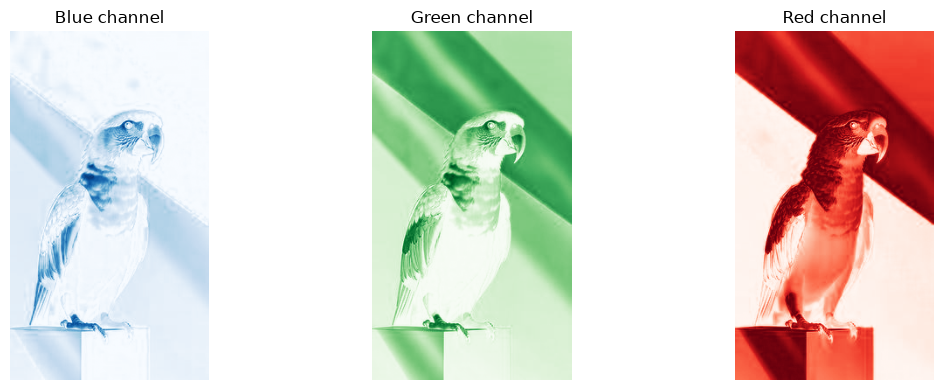

In [9]:
# Show channels
plt.figure(figsize=(12,4))

plt.subplot(1,3,1); plt.imshow(b , cmap = "Blues"); plt.title('Blue channel'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(g , cmap = "Greens"); plt.title('Green channel'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(r , cmap = "Reds"); plt.title('Red channel'); plt.axis('off')

plt.tight_layout()
plt.show()

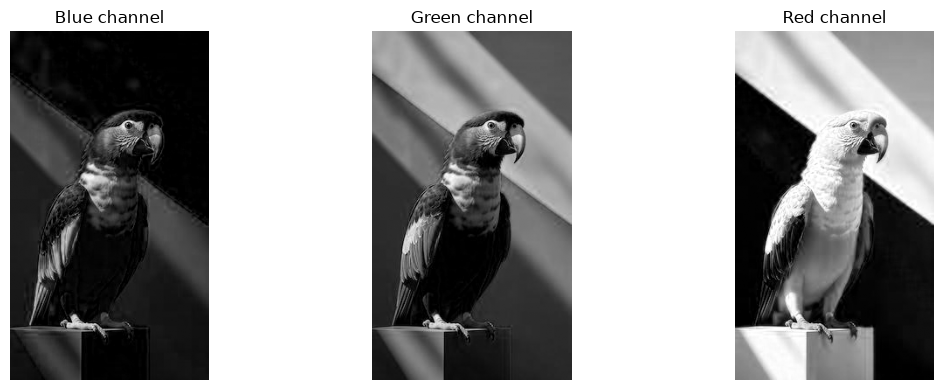

In [10]:
# Show channels
plt.figure(figsize=(12,4))

plt.subplot(1,3,1); plt.imshow(b , cmap = "gray"); plt.title('Blue channel'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(g , cmap = "gray"); plt.title('Green channel'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(r , cmap = "gray"); plt.title('Red channel'); plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))

Creates a new Matplotlib figure (a window/canvas).
figsize=(12,4) sets the figure size in inches (12 wide, 4 tall).

plt.subplot(1,3,1); plt.imshow(b, cmap='gray'); plt.title('Blue channel'); plt.axis('off')

plt.subplot(1,3,1) splits the figure into a grid of 1 row × 3 columns and selects the 1st panel.
plt.imshow(b, cmap='gray') displays the blue channel image (b).
cmap='gray' tells Matplotlib to render it as grayscale (0=black, 255=white style).
plt.title('Blue channel') sets the label above that panel.
plt.axis('off') hides x/y axes ticks and labels for a cleaner look.

For displaying single channels (B, G, or R) “in color”, you typically don’t use cmap='gray'. Instead, use cmap='Blues', cmap='Greens', and cmap='Reds' so each channel is tinted

In [11]:
cv2.imshow('Blue Channel', b)
cv2.waitKey(0)

-1

In [12]:
cv2.imshow('Green Channel', g)
cv2.waitKey(0)

-1

In [13]:
cv2.imshow('Red Channel', r)
cv2.waitKey(0)

-1

Phase 2: Preparing for Facial Recognition (Grayscale)
Grayscale removes color information entirely, representing pixels only by their intensity level from black to white
. This is highly useful for tasks like facial recognition where color isn't needed, and the focus is just on edges and shapes
. 4.  Convert: Use cv2.cvtColor() to convert your original image to Grayscale

(np.float64(-0.5), np.float64(227.5), np.float64(398.5), np.float64(-0.5))

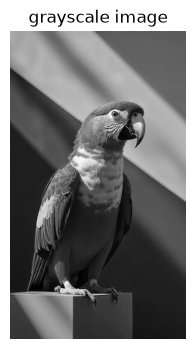

In [14]:
imggray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# cv2.imshow("Gray image", imggray)

plt.figure(figsize = (12,4))
plt.subplot(1,3,1); plt.imshow(imggray , cmap = 'gray'); plt.title('grayscale image'); plt.axis('off')

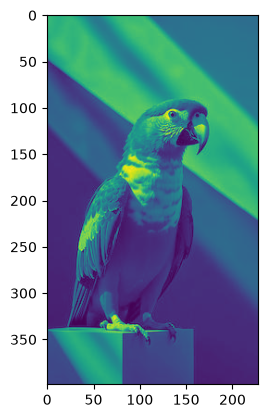

In [15]:
plt.imshow(img)
plt.imshow(imggray)

That happens because inside one notebook cell you may be plotting without calling plt.show() for each plot, and Matplotlib (especially in Jupyter) will often display only the last figure.

Fix: after each plt.imshow(...), either call plt.show()

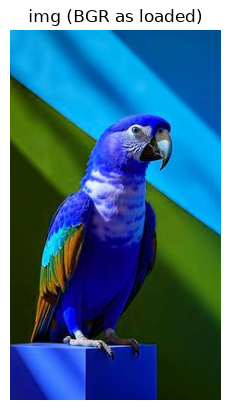

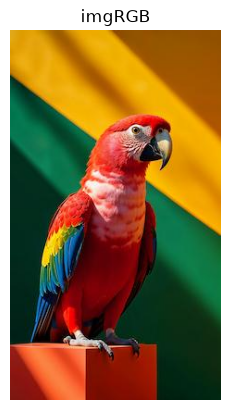

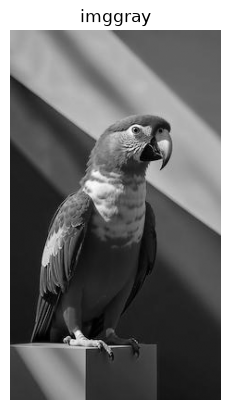

In [16]:

# to view each 
plt.figure()
plt.imshow(img)
plt.title("img (BGR as loaded)")
plt.axis("off")
plt.show()

imgRGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
plt.figure()
plt.imshow(imgRGB)
plt.title("imgRGB")
plt.axis("off")
plt.show()

plt.figure()
plt.imshow(imggray, cmap="gray")
plt.title("imggray")
plt.axis("off")
plt.show()


Phase 3: Preparing for Object Tracking (HSV)
To isolate specific colors effectively, we cannot rely on RGB/BGR. We must use HSV because it separates the actual color (Hue) from the vibrancy (Saturation) and brightness (Value)
. This makes object tracking much more resilient to varying lighting conditions
. 5.  Convert: Use cv2.cvtColor() to convert your original image to the HSV color space
. 6.  Concept check: Remember that in OpenCV, the Hue value ranges from 0 to 179, while Saturation and Value range from 0 to 255

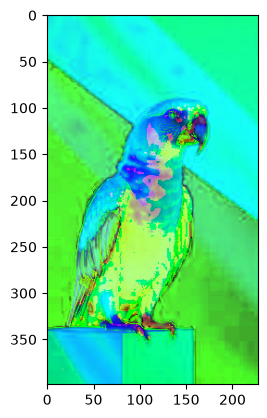

In [17]:
imghsv = cv2.cvtColor(img , cv2.COLOR_BGR2HSV)

plt.imshow(imghsv)

Bottom line: HSV can be converted from BGR, but for plt.imshow() you either (1) plot the separate channels, or (2) convert HSV back to BGR/RGB first.

HSV can be directly converted from BGR (that part is correct), but it should not be shown directly with plt.imshow(imghsv) because plt.imshow expects RGB-like channel encoding. OpenCV HSV uses different ranges (not RGB), so the colors appear wrong.

In [18]:
#imghsv = cv2.cvtColor(img , cv2.COLOR_BGR2HSV)

# plt.imshow(imghsv)
#cv2.imshow("hsv image" , imghsv)

Phase 4: Color Segmentation and Extraction
Now that you have your HSV image, you will isolate a specific color (like red) and delete the background. 7.  Create the Mask: Define your lower_red and upper_red boundaries, and use cv2.inRange(image_hsv, lower_red, upper_red) to create a binary mask
. 8.  Extract the Object: Use cv2.bitwise_and(image, image, mask=mask) to apply the mask
. 9.  Analyze: The final output should display only the areas containing your target color, with everything else turned completely black

hsv_masked = cv2.bitwise_and(imghsv, imghsv, mask=mask) 
why two times the same image is given as parameter ?

The cv2.bitwise_and() function is mathematically designed to compare the pixels of two different images and combine them. Because the function strictly requires two image inputs (a "source 1" and a "source 2"), passing the exact same image twice is essentially a workaround.
When you compare an image to itself, the result is just the exact same image. This allows the function to run without changing any of the original colors, perfectly setting the stage for the mask parameter to do the actual work of extracting the color


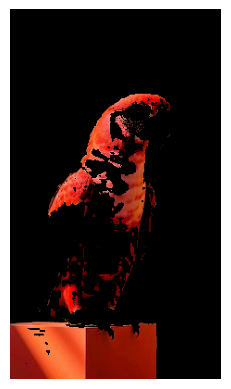

In [21]:
lower_red = np.array([0, 120, 70])
upper_red = np.array([10, 255, 255])

mask = cv2.inRange(imghsv, lower_red, upper_red)

# Apply mask in HSV space (zeros out pixels not in range)
hsv_masked = cv2.bitwise_and(imghsv, imghsv, mask=mask)

# Convert masked HSV back to BGR for display
bgr_masked = cv2.cvtColor(hsv_masked, cv2.COLOR_HSV2BGR)

# (optional) convert to RGB for plt
rgb_masked = cv2.cvtColor(bgr_masked, cv2.COLOR_BGR2RGB)

plt.imshow(rgb_masked)
plt.axis('off')
plt.show()